# Compare seed 00 across epsilon_ff simulations

Jupytext-compatible diagnostic for testing whether seed 00 uses the same
stellar population and formation sequence at epsilon_ff =
0.01, 0.03, 0.10, 0.30, and 1.00.

The analysis checks:

1. Primordial (t=0) component NAME values and masses.
2. Primordial binary pairings.
3. Every later SINGLE/BINARY record in gradual.97.
4. Exact formation-event ordering.
5. Initial masses and binary membership for every event.
6. Whether formation times differ only by a simple rescaling.

It deliberately compares formation inputs rather than evolved snapshots,
since dynamics can make otherwise identical runs diverge after stars form.

Run directly:

    python compare_seed00_across_eff.py

Or convert to a notebook:

    jupytext --to notebook compare_seed00_across_eff.py

Outputs are written to ./seed00_eff_comparison_outputs/

In [1]:
from __future__ import annotations

import math
import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nbody62spisea import converter

particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
ROOT = Path(
    "/standard/Tan_JC/backup_protoclusters/multiples/"
    "M3000new/sigma0p1/fiducial"
)

EFF_DIRS = {
    0.01: "sfe_ff001",
    0.03: "sfe_ff003",
    0.10: "sfe_ff010",
    0.30: "sfe_ff030",
    1.00: "sfe_ff100",
}

SEED = "00"

# Use the run from which we currently build the instantaneous case as the
# primary reference.
REFERENCE_EFF = 0.03

# The current simulations use NAME=1...150 as the primordial components.
N_PRIMORDIAL_COMPONENTS = 150

MASS_ATOL = 1.0e-10
MASS_RTOL = 1.0e-8
TIME_ATOL = 1.0e-10

OUTPUT_DIR = Path.cwd() / "seed00_eff_comparison_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True
SHOW_FIGURES = True

## Small helpers

In [3]:
def show_table(df: pd.DataFrame, n: int | None = None) -> None:
    """Display nicely in Jupyter, or print when run as a script."""
    if n is not None:
        df = df.head(n)

    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))


def simulation_path(eff: float) -> Path:
    path = ROOT / EFF_DIRS[eff] / SEED
    if not path.is_dir():
        raise FileNotFoundError(path)
    return path


def finish_figure(fig, filename: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / filename,
            dpi=220,
            bbox_inches="tight",
        )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def mass_close(a, b) -> np.ndarray:
    return np.isclose(
        np.asarray(a, dtype=float),
        np.asarray(b, dtype=float),
        atol=MASS_ATOL,
        rtol=MASS_RTOL,
        equal_nan=True,
    )

## Parse gradual.97 while preserving file order

This is the most important comparison for the "same seed, different rate"
hypothesis.  Each SINGLE/BINARY line is treated as one star-formation event,
and `event_index` records its exact order in gradual.97.

In [4]:
def parse_gradual_formation_file(
    simulation_path: Path | str,
    eff: float,
) -> pd.DataFrame:
    gradual_path = Path(simulation_path) / "gradual.97"

    if not gradual_path.is_file():
        raise FileNotFoundError(gradual_path)

    rows: list[dict[str, Any]] = []
    event_index = 0

    with gradual_path.open() as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()

            if not stripped:
                continue

            fields = stripped.split()

            if len(fields) < 2 or fields[1] == "TIME":
                continue

            record_type = fields[0].upper()

            if record_type not in {"SINGLE", "BINARY"}:
                continue

            try:
                formation_time = float(fields[2])

                if record_type == "SINGLE":
                    primary_name = int(fields[3])
                    companion_name = -1
                    primary_mass = float(fields[4])
                    companion_mass = np.nan

                else:
                    primary_name = int(fields[3])
                    companion_name = int(fields[4])
                    primary_mass = float(fields[5])
                    companion_mass = float(fields[6])

            except (IndexError, ValueError, TypeError) as exc:
                raise RuntimeError(
                    f"Could not parse {gradual_path}, line {line_number}:\n"
                    f"{line.rstrip()}"
                ) from exc

            rows.append({
                "epsilon_ff": float(eff),
                "event_index": int(event_index),
                "source_line": int(line_number),
                "event_type": record_type,
                "formation_time_myr": float(formation_time),
                "primary_name": int(primary_name),
                "companion_name": int(companion_name),
                "primary_mass": float(primary_mass),
                "companion_mass": float(companion_mass),
                "system_mass": float(
                    primary_mass
                    + (0.0 if not np.isfinite(companion_mass)
                       else companion_mass)
                ),
            })

            event_index += 1

    if not rows:
        raise RuntimeError(
            f"No SINGLE/BINARY formation events found in {gradual_path}"
        )

    return pd.DataFrame(rows)

## Reconstruct the primordial t=0 population

This follows the same logic used in the finite-versus-instantaneous script:
binary systems are reconstructed first, and their component NAME values are
removed from the candidate-single population.

In [5]:
def primordial_population(
    simulation_path: Path | str,
    eff: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    data = converter.get_binary_data(
        os.path.abspath(str(simulation_path)),
        0,
    )

    candidate_single_names = np.asarray(data["single"], dtype=int)
    candidate_single_masses = np.asarray(data["msingle"], dtype=float)

    primary_names = np.asarray(data["primary"], dtype=int)
    secondary_names = np.asarray(data["secondary"], dtype=int)
    primary_masses = np.asarray(data["m1"], dtype=float)
    secondary_masses = np.asarray(data["m2"], dtype=float)

    primordial_binary_mask = (
        (primary_names >= 1)
        & (primary_names <= N_PRIMORDIAL_COMPONENTS)
        & (secondary_names >= 1)
        & (secondary_names <= N_PRIMORDIAL_COMPONENTS)
    )

    p_names = primary_names[primordial_binary_mask]
    s_names = secondary_names[primordial_binary_mask]
    p_masses = primary_masses[primordial_binary_mask]
    s_masses = secondary_masses[primordial_binary_mask]

    binary_components = np.concatenate([p_names, s_names])

    single_mask = (
        (candidate_single_names >= 1)
        & (candidate_single_names <= N_PRIMORDIAL_COMPONENTS)
        & ~np.isin(candidate_single_names, binary_components)
    )

    single_names = candidate_single_names[single_mask]
    single_masses = candidate_single_masses[single_mask]

    # Component-level table: one row per physical star.
    component_rows: list[dict[str, Any]] = []

    for name, mass in zip(single_names, single_masses):
        component_rows.append({
            "epsilon_ff": float(eff),
            "name": int(name),
            "initial_mass": float(mass),
            "multiplicity": "single",
            "binary_partner": -1,
        })

    for primary, secondary, m1, m2 in zip(
        p_names, s_names, p_masses, s_masses
    ):
        component_rows.append({
            "epsilon_ff": float(eff),
            "name": int(primary),
            "initial_mass": float(m1),
            "multiplicity": "binary_primary",
            "binary_partner": int(secondary),
        })
        component_rows.append({
            "epsilon_ff": float(eff),
            "name": int(secondary),
            "initial_mass": float(m2),
            "multiplicity": "binary_secondary",
            "binary_partner": int(primary),
        })

    components = (
        pd.DataFrame(component_rows)
        .sort_values("name")
        .reset_index(drop=True)
    )

    binary_rows = pd.DataFrame({
        "epsilon_ff": float(eff),
        "primary_name": p_names,
        "secondary_name": s_names,
        "primary_mass": p_masses,
        "secondary_mass": s_masses,
    }).sort_values(
        ["primary_name", "secondary_name"]
    ).reset_index(drop=True)

    expected_names = set(range(1, N_PRIMORDIAL_COMPONENTS + 1))
    recovered_names = set(components["name"].astype(int))

    missing = sorted(expected_names - recovered_names)
    unexpected = sorted(recovered_names - expected_names)

    if missing or unexpected:
        raise RuntimeError(
            f"Primordial reconstruction failed for epsilon_ff={eff}.\n"
            f"Missing NAME values: {missing}\n"
            f"Unexpected NAME values: {unexpected}"
        )

    if components["name"].duplicated().any():
        duplicated = components.loc[
            components["name"].duplicated(keep=False), "name"
        ].tolist()
        raise RuntimeError(
            f"Duplicate primordial NAME values for epsilon_ff={eff}: "
            f"{duplicated}"
        )

    return components, binary_rows

## Load all five simulations

In [6]:
formation_tables: dict[float, pd.DataFrame] = {}
primordial_components: dict[float, pd.DataFrame] = {}
primordial_binaries: dict[float, pd.DataFrame] = {}

for eff in EFF_DIRS:
    path = simulation_path(eff)

    print("=" * 80)
    print(f"epsilon_ff = {eff:.2f}")
    print(path)

    formation_tables[eff] = parse_gradual_formation_file(
        path,
        eff,
    )

    (
        primordial_components[eff],
        primordial_binaries[eff],
    ) = primordial_population(
        path,
        eff,
    )

    print(
        f"  primordial components: "
        f"{len(primordial_components[eff])}"
    )
    print(
        f"  primordial binaries:   "
        f"{len(primordial_binaries[eff])}"
    )
    print(
        f"  gradual events:         "
        f"{len(formation_tables[eff])}"
    )
    print(
        f"  gradual components:     "
        f"{len(formation_tables[eff]) + (formation_tables[eff]['event_type'] == 'BINARY').sum()}"
    )

epsilon_ff = 0.01
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff001/00


  primordial components: 150
  primordial binaries:   56
  gradual events:         2766
  gradual components:     4140


epsilon_ff = 0.03
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff003/00


  primordial components: 150
  primordial binaries:   48
  gradual events:         2720
  gradual components:     4083
epsilon_ff = 0.10
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff010/00


  primordial components: 150
  primordial binaries:   50
  gradual events:         2431
  gradual components:     3646


epsilon_ff = 0.30
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff030/00


  primordial components: 150
  primordial binaries:   51
  gradual events:         2373
  gradual components:     3558
epsilon_ff = 1.00
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff100/00


  primordial components: 150
  primordial binaries:   51
  gradual events:         2249
  gradual components:     3372


## Compare primordial populations to epsilon_ff = 0.03

In [7]:
def compare_primordial(
    reference: pd.DataFrame,
    target: pd.DataFrame,
    target_eff: float,
) -> tuple[dict[str, Any], pd.DataFrame]:
    merged = reference.merge(
        target,
        on="name",
        how="outer",
        suffixes=("_ref", "_target"),
        indicator=True,
    )

    merged["mass_match"] = mass_close(
        merged["initial_mass_ref"],
        merged["initial_mass_target"],
    )

    merged["multiplicity_match"] = (
        merged["multiplicity_ref"]
        == merged["multiplicity_target"]
    )

    merged["partner_match"] = (
        merged["binary_partner_ref"]
        == merged["binary_partner_target"]
    )

    merged["exact_component_match"] = (
        (merged["_merge"] == "both")
        & merged["mass_match"]
        & merged["multiplicity_match"]
        & merged["partner_match"]
    )

    both = merged["_merge"] == "both"

    if both.any():
        mass_abs_diff = np.abs(
            merged.loc[both, "initial_mass_target"]
            - merged.loc[both, "initial_mass_ref"]
        )
        max_mass_diff = float(mass_abs_diff.max())
    else:
        max_mass_diff = np.nan

    summary = {
        "epsilon_ff": float(target_eff),
        "n_reference_components": int(len(reference)),
        "n_target_components": int(len(target)),
        "same_name_set": bool(
            set(reference["name"]) == set(target["name"])
        ),
        "all_masses_match": bool(
            both.all()
            and merged.loc[both, "mass_match"].all()
            and len(reference) == len(target)
        ),
        "all_multiplicity_match": bool(
            both.all()
            and merged.loc[both, "multiplicity_match"].all()
            and len(reference) == len(target)
        ),
        "all_binary_partners_match": bool(
            both.all()
            and merged.loc[both, "partner_match"].all()
            and len(reference) == len(target)
        ),
        "all_primordial_components_match": bool(
            merged["exact_component_match"].all()
            and len(reference) == len(target)
        ),
        "max_abs_mass_difference": max_mass_diff,
        "n_component_mismatches": int(
            (~merged["exact_component_match"]).sum()
        ),
    }

    return summary, merged


primordial_summary_rows = []
primordial_mismatch_tables = []

prim_ref = primordial_components[REFERENCE_EFF]

for eff in EFF_DIRS:
    summary, details = compare_primordial(
        prim_ref,
        primordial_components[eff],
        eff,
    )

    primordial_summary_rows.append(summary)

    mismatches = details[
        ~details["exact_component_match"]
    ].copy()

    if len(mismatches):
        mismatches.insert(0, "target_epsilon_ff", eff)
        primordial_mismatch_tables.append(mismatches)

df_primordial_summary = pd.DataFrame(
    primordial_summary_rows
)

if primordial_mismatch_tables:
    df_primordial_mismatches = pd.concat(
        primordial_mismatch_tables,
        ignore_index=True,
    )
else:
    df_primordial_mismatches = pd.DataFrame()

print("\nPrimordial comparison against epsilon_ff=0.03:")
show_table(df_primordial_summary)


Primordial comparison against epsilon_ff=0.03:


,epsilon_ff,n_reference_components,n_target_components,same_name_set,all_masses_match,all_multiplicity_match,all_binary_partners_match,all_primordial_components_match,max_abs_mass_difference,n_component_mismatches
0,0.01,150,150,True,False,False,False,False,4.048491,150
1,0.03,150,150,True,True,True,True,True,0.000000,0
2,0.10,150,150,True,False,False,False,False,3.935967,150
3,0.30,150,150,True,False,False,False,False,35.490523,150
4,1.00,150,150,True,False,False,False,False,7.728385,150


## Compare gradual.97 event identity and order

If the same random seed generates the same stellar population in the same
order, then at every event index we should have the same:

- SINGLE/BINARY type
- primary NAME
- companion NAME
- primary mass
- companion mass

Formation time is intentionally excluded from the identity test.

In [8]:
def compare_formation_sequence(
    reference: pd.DataFrame,
    target: pd.DataFrame,
    target_eff: float,
) -> tuple[dict[str, Any], pd.DataFrame]:
    n_common = min(len(reference), len(target))

    ref = reference.iloc[:n_common].reset_index(drop=True)
    tar = target.iloc[:n_common].reset_index(drop=True)

    comparison = pd.DataFrame({
        "event_index": np.arange(n_common, dtype=int),

        "ref_type": ref["event_type"],
        "target_type": tar["event_type"],

        "ref_primary": ref["primary_name"],
        "target_primary": tar["primary_name"],

        "ref_companion": ref["companion_name"],
        "target_companion": tar["companion_name"],

        "ref_primary_mass": ref["primary_mass"],
        "target_primary_mass": tar["primary_mass"],

        "ref_companion_mass": ref["companion_mass"],
        "target_companion_mass": tar["companion_mass"],

        "ref_time_myr": ref["formation_time_myr"],
        "target_time_myr": tar["formation_time_myr"],
    })

    comparison["type_match"] = (
        comparison["ref_type"]
        == comparison["target_type"]
    )
    comparison["primary_name_match"] = (
        comparison["ref_primary"]
        == comparison["target_primary"]
    )
    comparison["companion_name_match"] = (
        comparison["ref_companion"]
        == comparison["target_companion"]
    )
    comparison["primary_mass_match"] = mass_close(
        comparison["ref_primary_mass"],
        comparison["target_primary_mass"],
    )
    comparison["companion_mass_match"] = mass_close(
        comparison["ref_companion_mass"],
        comparison["target_companion_mass"],
    )

    comparison["event_identity_match"] = (
        comparison["type_match"]
        & comparison["primary_name_match"]
        & comparison["companion_name_match"]
        & comparison["primary_mass_match"]
        & comparison["companion_mass_match"]
    )

    first_mismatch = comparison.loc[
        ~comparison["event_identity_match"],
        "event_index",
    ]

    summary = {
        "epsilon_ff": float(target_eff),
        "n_reference_events": int(len(reference)),
        "n_target_events": int(len(target)),
        "same_event_count": bool(len(reference) == len(target)),
        "all_event_types_match": bool(
            len(reference) == len(target)
            and comparison["type_match"].all()
        ),
        "all_primary_names_match": bool(
            len(reference) == len(target)
            and comparison["primary_name_match"].all()
        ),
        "all_companion_names_match": bool(
            len(reference) == len(target)
            and comparison["companion_name_match"].all()
        ),
        "all_primary_masses_match": bool(
            len(reference) == len(target)
            and comparison["primary_mass_match"].all()
        ),
        "all_companion_masses_match": bool(
            len(reference) == len(target)
            and comparison["companion_mass_match"].all()
        ),
        "exact_same_event_sequence": bool(
            len(reference) == len(target)
            and comparison["event_identity_match"].all()
        ),
        "n_event_identity_mismatches_in_common_range": int(
            (~comparison["event_identity_match"]).sum()
        ),
        "first_mismatch_event_index": (
            int(first_mismatch.iloc[0])
            if len(first_mismatch)
            else np.nan
        ),
    }

    return summary, comparison


formation_summary_rows = []
formation_comparisons: dict[float, pd.DataFrame] = {}
formation_mismatch_tables = []

formation_ref = formation_tables[REFERENCE_EFF]

for eff in EFF_DIRS:
    summary, comparison = compare_formation_sequence(
        formation_ref,
        formation_tables[eff],
        eff,
    )

    formation_summary_rows.append(summary)
    formation_comparisons[eff] = comparison

    mismatches = comparison[
        ~comparison["event_identity_match"]
    ].copy()

    if len(mismatches):
        mismatches.insert(0, "target_epsilon_ff", eff)
        formation_mismatch_tables.append(mismatches)

df_formation_summary = pd.DataFrame(
    formation_summary_rows
)

if formation_mismatch_tables:
    df_formation_mismatches = pd.concat(
        formation_mismatch_tables,
        ignore_index=True,
    )
else:
    df_formation_mismatches = pd.DataFrame()

print("\nFormation-sequence comparison against epsilon_ff=0.03:")
show_table(df_formation_summary)


Formation-sequence comparison against epsilon_ff=0.03:


,epsilon_ff,n_reference_events,n_target_events,same_event_count,all_event_types_match,all_primary_names_match,all_companion_names_match,all_primary_masses_match,all_companion_masses_match,exact_same_event_sequence,n_event_identity_mismatches_in_common_range,first_mismatch_event_index
0,0.01,2720,2766,False,False,False,False,False,False,False,2720,0.0
1,0.03,2720,2720,True,True,True,True,True,True,True,0,NaN
2,0.10,2720,2431,False,False,False,False,False,False,False,2431,0.0
3,0.30,2720,2373,False,False,False,False,False,False,False,2373,0.0
4,1.00,2720,2249,False,False,False,False,False,False,False,2249,0.0


## Compare the complete stellar component population

This ignores event order and asks a second, independent question:
do all simulations ultimately contain the same component NAME values,
initial masses, and binary partners?

In [9]:
def component_catalog_from_gradual(df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for row in df.itertuples(index=False):
        if row.event_type == "SINGLE":
            rows.append({
                "name": int(row.primary_name),
                "initial_mass": float(row.primary_mass),
                "event_index": int(row.event_index),
                "formation_time_myr": float(row.formation_time_myr),
                "event_type": "SINGLE",
                "binary_partner": -1,
            })
        else:
            rows.append({
                "name": int(row.primary_name),
                "initial_mass": float(row.primary_mass),
                "event_index": int(row.event_index),
                "formation_time_myr": float(row.formation_time_myr),
                "event_type": "BINARY_PRIMARY",
                "binary_partner": int(row.companion_name),
            })
            rows.append({
                "name": int(row.companion_name),
                "initial_mass": float(row.companion_mass),
                "event_index": int(row.event_index),
                "formation_time_myr": float(row.formation_time_myr),
                "event_type": "BINARY_SECONDARY",
                "binary_partner": int(row.primary_name),
            })

    return (
        pd.DataFrame(rows)
        .sort_values("name")
        .reset_index(drop=True)
    )


gradual_component_catalogs = {
    eff: component_catalog_from_gradual(df)
    for eff, df in formation_tables.items()
}


def compare_component_catalogs(
    reference: pd.DataFrame,
    target: pd.DataFrame,
    target_eff: float,
) -> dict[str, Any]:
    merged = reference.merge(
        target,
        on="name",
        how="outer",
        suffixes=("_ref", "_target"),
        indicator=True,
    )

    both = merged["_merge"] == "both"

    mass_match = np.zeros(len(merged), dtype=bool)
    mass_match[both] = mass_close(
        merged.loc[both, "initial_mass_ref"],
        merged.loc[both, "initial_mass_target"],
    )

    partner_match = (
        merged["binary_partner_ref"]
        == merged["binary_partner_target"]
    ).fillna(False)

    role_match = (
        merged["event_type_ref"]
        == merged["event_type_target"]
    ).fillna(False)

    event_index_match = (
        merged["event_index_ref"]
        == merged["event_index_target"]
    ).fillna(False)

    exact = (
        both
        & mass_match
        & partner_match
        & role_match
        & event_index_match
    )

    return {
        "epsilon_ff": float(target_eff),
        "same_component_name_set": bool(
            set(reference["name"]) == set(target["name"])
        ),
        "same_component_masses": bool(
            both.all()
            and mass_match[both].all()
            and len(reference) == len(target)
        ),
        "same_binary_membership": bool(
            both.all()
            and partner_match[both].all()
            and role_match[both].all()
            and len(reference) == len(target)
        ),
        "same_component_event_indices": bool(
            both.all()
            and event_index_match[both].all()
            and len(reference) == len(target)
        ),
        "complete_gradual_component_match": bool(
            exact.all()
            and len(reference) == len(target)
        ),
    }


component_summary_rows = []

component_ref = gradual_component_catalogs[REFERENCE_EFF]

for eff in EFF_DIRS:
    component_summary_rows.append(
        compare_component_catalogs(
            component_ref,
            gradual_component_catalogs[eff],
            eff,
        )
    )

df_component_summary = pd.DataFrame(
    component_summary_rows
)

print("\nComplete gradual-component comparison:")
show_table(df_component_summary)


Complete gradual-component comparison:


,epsilon_ff,same_component_name_set,same_component_masses,same_binary_membership,same_component_event_indices,complete_gradual_component_match
0,0.01,False,False,False,False,False
1,0.03,True,True,True,True,True
2,0.10,False,False,False,False,False
3,0.30,False,False,False,False,False
4,1.00,False,False,False,False,False


## Formation-time scaling test

If changing epsilon_ff only changes the rate at which an otherwise identical
sequence is introduced, formation times should be a deterministic monotonic
mapping of the epsilon_ff=0.03 times.

We test two versions:

1. Best unconstrained linear mapping:

      t_target = intercept + slope * t_ref

2. Simple inverse-epsilon expectation:

      t_target ~= t_ref * (epsilon_ref / epsilon_target)

The second relation is a useful diagnostic, not an assumption required by
the identity test.

In [10]:
def time_scaling_statistics(
    reference: pd.DataFrame,
    target: pd.DataFrame,
    target_eff: float,
) -> dict[str, Any]:
    comparison = formation_comparisons[target_eff]

    # Only compare time scaling where the formation event itself is identical.
    good = (
        comparison["event_identity_match"]
        & np.isfinite(comparison["ref_time_myr"])
        & np.isfinite(comparison["target_time_myr"])
    )

    x = comparison.loc[good, "ref_time_myr"].to_numpy(float)
    y = comparison.loc[good, "target_time_myr"].to_numpy(float)

    if len(x) < 2:
        return {
            "epsilon_ff": float(target_eff),
            "n_identical_events_used": int(len(x)),
        }

    # y = intercept + slope*x
    slope, intercept = np.polyfit(x, y, 1)
    y_fit = intercept + slope * x

    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = (
        1.0 - ss_res / ss_tot
        if ss_tot > 0
        else (1.0 if ss_res <= TIME_ATOL else np.nan)
    )

    residual = y - y_fit

    expected_slope = REFERENCE_EFF / target_eff
    y_inverse = x * expected_slope
    inverse_residual = y - y_inverse

    positive_time = np.abs(x) > TIME_ATOL

    if positive_time.any():
        ratios = y[positive_time] / x[positive_time]
        median_ratio = float(np.median(ratios))
        ratio_std = float(np.std(ratios))
    else:
        median_ratio = np.nan
        ratio_std = np.nan

    # Rank preservation is another way to ask whether stars form in the same
    # temporal ordering even if the mapping is not perfectly linear.
    order_ref = np.argsort(x, kind="stable")
    order_target = np.argsort(y, kind="stable")
    identical_time_rank_order = bool(
        np.array_equal(order_ref, order_target)
    )

    return {
        "epsilon_ff": float(target_eff),
        "n_identical_events_used": int(len(x)),
        "linear_intercept_myr": float(intercept),
        "linear_slope": float(slope),
        "linear_r2": float(r2),
        "linear_max_abs_residual_myr": float(
            np.max(np.abs(residual))
        ),
        "linear_rms_residual_myr": float(
            np.sqrt(np.mean(residual**2))
        ),
        "expected_inverse_epsilon_slope": float(expected_slope),
        "slope_divided_by_inverse_epsilon_expectation": float(
            slope / expected_slope
        ),
        "inverse_epsilon_max_abs_residual_myr": float(
            np.max(np.abs(inverse_residual))
        ),
        "inverse_epsilon_rms_residual_myr": float(
            np.sqrt(np.mean(inverse_residual**2))
        ),
        "median_target_over_reference_time": median_ratio,
        "std_target_over_reference_time": ratio_std,
        "identical_formation_time_rank_order": identical_time_rank_order,
    }


time_scaling_rows = [
    time_scaling_statistics(
        formation_ref,
        formation_tables[eff],
        eff,
    )
    for eff in EFF_DIRS
]

df_time_scaling = pd.DataFrame(
    time_scaling_rows
)

print("\nFormation-time scaling relative to epsilon_ff=0.03:")
show_table(df_time_scaling)


Formation-time scaling relative to epsilon_ff=0.03:


,epsilon_ff,n_identical_events_used,linear_intercept_myr,linear_slope,linear_r2,linear_max_abs_residual_myr,linear_rms_residual_myr,expected_inverse_epsilon_slope,slope_divided_by_inverse_epsilon_expectation,inverse_epsilon_max_abs_residual_myr,inverse_epsilon_rms_residual_myr,median_target_over_reference_time,std_target_over_reference_time,identical_formation_time_rank_order
0,0.01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.03,2720,3.565201e-16,1.0,1.0,4.440892e-16,3.417022e-16,1.0,1.0,0.0,0.0,1.0,0.0,True
2,0.10,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.30,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Formation-time plots

In [11]:
for eff in EFF_DIRS:
    if math.isclose(eff, REFERENCE_EFF):
        continue

    comparison = formation_comparisons[eff]

    good = (
        comparison["event_identity_match"]
        & np.isfinite(comparison["ref_time_myr"])
        & np.isfinite(comparison["target_time_myr"])
    )

    if good.sum() < 2:
        continue

    x = comparison.loc[good, "ref_time_myr"].to_numpy(float)
    y = comparison.loc[good, "target_time_myr"].to_numpy(float)

    row = df_time_scaling[
        df_time_scaling["epsilon_ff"] == eff
    ].iloc[0]

    fig, ax = plt.subplots(
        figsize=(7.2, 6.0),
        constrained_layout=True,
    )

    ax.scatter(
        x,
        y,
        s=13,
        alpha=0.55,
        edgecolors="none",
        label="formation events",
    )

    xx = np.linspace(
        min(0.0, float(np.min(x))),
        float(np.max(x)),
        300,
    )

    ax.plot(
        xx,
        row["linear_intercept_myr"]
        + row["linear_slope"] * xx,
        lw=1.8,
        label=(
            "best linear fit\n"
            f"slope={row['linear_slope']:.6g}, "
            f"$R^2$={row['linear_r2']:.8f}"
        ),
    )

    expected = REFERENCE_EFF / eff

    ax.plot(
        xx,
        expected * xx,
        lw=1.5,
        ls="--",
        label=(
            r"$t_{\rm target}=t_{0.03}(0.03/\epsilon_{\rm ff})$"
            f"\nexpected slope={expected:.6g}"
        ),
    )

    ax.set_xlabel(
        r"Formation time for $\epsilon_{\rm ff}=0.03$ [Myr]"
    )
    ax.set_ylabel(
        rf"Formation time for $\epsilon_{{\rm ff}}={eff:.2f}$ [Myr]"
    )
    ax.set_title(
        "Seed 00 formation-time mapping"
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

    finish_figure(
        fig,
        f"formation_time_mapping_eff{eff:.2f}.png",
    )

## Formation time versus event index

If all simulations have an identical event sequence, these curves represent
the same stars/systems appearing in the same order, with only the timing
changed.

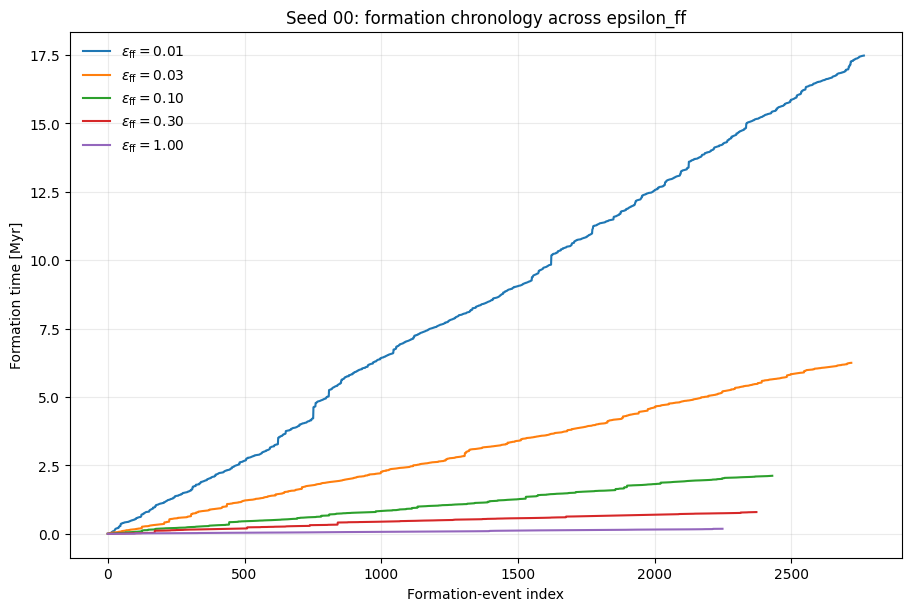

In [12]:
fig, ax = plt.subplots(
    figsize=(9.0, 6.0),
    constrained_layout=True,
)

for eff, df in formation_tables.items():
    ax.plot(
        df["event_index"],
        df["formation_time_myr"],
        lw=1.5,
        label=rf"$\epsilon_{{\rm ff}}={eff:.2f}$",
    )

ax.set_xlabel("Formation-event index")
ax.set_ylabel("Formation time [Myr]")
ax.set_title("Seed 00: formation chronology across epsilon_ff")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

finish_figure(
    fig,
    "formation_time_vs_event_index.png",
)

## Formation time after multiplying by epsilon_ff

For a pure 1/epsilon_ff rescaling, epsilon_ff * t should collapse onto the
same curve for every simulation.

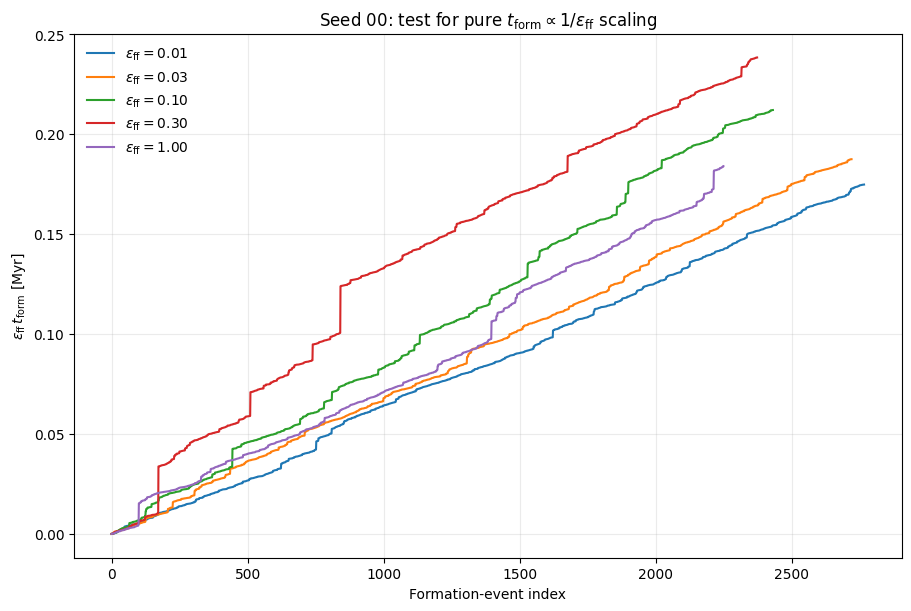

In [13]:
fig, ax = plt.subplots(
    figsize=(9.0, 6.0),
    constrained_layout=True,
)

for eff, df in formation_tables.items():
    ax.plot(
        df["event_index"],
        eff * df["formation_time_myr"],
        lw=1.5,
        label=rf"$\epsilon_{{\rm ff}}={eff:.2f}$",
    )

ax.set_xlabel("Formation-event index")
ax.set_ylabel(
    r"$\epsilon_{\rm ff}\,t_{\rm form}$ [Myr]"
)
ax.set_title(
    r"Seed 00: test for pure $t_{\rm form}\propto1/\epsilon_{\rm ff}$ scaling"
)
ax.grid(alpha=0.25)
ax.legend(frameon=False)

finish_figure(
    fig,
    "epsilon_times_formation_time_vs_event_index.png",
)

## Save machine-readable results

In [14]:
df_primordial_summary.to_csv(
    OUTPUT_DIR / "primordial_comparison_summary.csv",
    index=False,
)

df_formation_summary.to_csv(
    OUTPUT_DIR / "formation_sequence_summary.csv",
    index=False,
)

df_component_summary.to_csv(
    OUTPUT_DIR / "gradual_component_summary.csv",
    index=False,
)

df_time_scaling.to_csv(
    OUTPUT_DIR / "formation_time_scaling_summary.csv",
    index=False,
)

if not df_primordial_mismatches.empty:
    df_primordial_mismatches.to_csv(
        OUTPUT_DIR / "primordial_mismatches.csv",
        index=False,
    )

if not df_formation_mismatches.empty:
    df_formation_mismatches.to_csv(
        OUTPUT_DIR / "formation_sequence_mismatches.csv",
        index=False,
    )

for eff, df in formation_tables.items():
    tag = EFF_DIRS[eff]
    df.to_csv(
        OUTPUT_DIR / f"{tag}_seed00_gradual_events.csv",
        index=False,
    )

## Final verdict

The strongest version of the hypothesis requires BOTH:

- all primordial components to be identical; and
- every later gradual.97 formation event to be identical and in exactly the
  same order.

The timing does NOT need to follow a perfect 1/epsilon_ff law for the
instantaneous-population construction to use the same stellar population.
That scaling test is reported separately.

In [15]:
verdict_rows = []

for eff in EFF_DIRS:
    prim = df_primordial_summary.loc[
        df_primordial_summary["epsilon_ff"] == eff
    ].iloc[0]

    form = df_formation_summary.loc[
        df_formation_summary["epsilon_ff"] == eff
    ].iloc[0]

    comp = df_component_summary.loc[
        df_component_summary["epsilon_ff"] == eff
    ].iloc[0]

    verdict_rows.append({
        "epsilon_ff": eff,
        "same_primordial_population": bool(
            prim["all_primordial_components_match"]
        ),
        "same_gradual_event_sequence": bool(
            form["exact_same_event_sequence"]
        ),
        "same_complete_gradual_population": bool(
            comp["complete_gradual_component_match"]
        ),
        "same_seed_population_and_order": bool(
            prim["all_primordial_components_match"]
            and form["exact_same_event_sequence"]
            and comp["complete_gradual_component_match"]
        ),
    })

df_verdict = pd.DataFrame(verdict_rows)

df_verdict.to_csv(
    OUTPUT_DIR / "final_seed_identity_verdict.csv",
    index=False,
)

print("\n" + "=" * 80)
print("FINAL SEED-IDENTITY VERDICT")
print("=" * 80)
show_table(df_verdict)

non_reference = df_verdict[
    ~np.isclose(
        df_verdict["epsilon_ff"],
        REFERENCE_EFF,
    )
]

all_same = bool(
    non_reference["same_seed_population_and_order"].all()
)

print()
if all_same:
    print(
        "RESULT: seed 00 has the same primordial population and the "
        "same gradual.97 stellar formation sequence across every "
        "epsilon_ff value tested."
    )
    print(
        "This supports using the epsilon_ff=0.03 seed-00 population "
        "as the source population for an instantaneous-formation "
        "control, provided the intended control changes only stellar "
        "formation times."
    )
else:
    print(
        "RESULT: at least one epsilon_ff run differs in primordial "
        "population, stellar identities/masses, binary pairing, or "
        "formation-event order."
    )
    print(
        "Inspect formation_sequence_mismatches.csv and/or "
        "primordial_mismatches.csv before treating one finite run as "
        "a universal seed-00 source population."
    )

print()
print(f"Outputs written to: {OUTPUT_DIR.resolve()}")


FINAL SEED-IDENTITY VERDICT


,epsilon_ff,same_primordial_population,same_gradual_event_sequence,same_complete_gradual_population,same_seed_population_and_order
0,0.01,False,False,False,False
1,0.03,True,True,True,True
2,0.10,False,False,False,False
3,0.30,False,False,False,False
4,1.00,False,False,False,False



RESULT: at least one epsilon_ff run differs in primordial population, stellar identities/masses, binary pairing, or formation-event order.
Inspect formation_sequence_mismatches.csv and/or primordial_mismatches.csv before treating one finite run as a universal seed-00 source population.

Outputs written to: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-06_compare-seeds-across-e_ff/seed00_eff_comparison_outputs
